In [1]:
import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)
from matplotlib import patches
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

raw_data = Table().read_table("Leases.csv")
finance = raw_data.where('internal_industry', are.equal_to('Financial Services and Insurance')).where('leasedSF', are.above_or_equal_to(10000))
tech = raw_data.where('internal_industry', are.equal_to('Technology, Advertising, Media, and Information')).where('leasedSF', are.above_or_equal_to(10000))
legal = raw_data.where('internal_industry', are.equal_to('Legal Services')).where('leasedSF', are.above_or_equal_to(10000))
tenthousand = raw_data.where('leasedSF', are.above_or_equal_to(10000))

In [2]:
tech.column('leasedSF')

array([  15795.,   49914.,   12000., ...,  110881.,  128743.,   18745.])

In [2]:
duringCovidTech = tech.where('year', are.above_or_equal_to(2020)).where('year', are.below(2022))

In [3]:
duringCovidTech = tech.where('year', are.above_or_equal_to(2020)).where('year', are.below(2022))
preCovidTech = tech.where('year', are.below(2020))
postCovidTech = tech.where('year', are.above_or_equal_to(2022))
small_cutoff = 40000
medium_cutoff = 150000
techPostCovidSmall = postCovidTech
techPreCovidSmall = preCovidTech
TechDuringSmall = duringCovidTech
techPostCovidMedium = duringCovidTech.where('leasedSF', are.above_or_equal_to(small_cutoff)).where('leasedSF', are.below(medium_cutoff))
techPostCovidLarge = duringCovidTech.where('leasedSF', are.above_or_equal_to(medium_cutoff))

In [4]:
#major market cities POST

#alpha++
NY = techPostCovidSmall.where('city', are.equal_to('New York'))

#alpha
LA = techPostCovidSmall.where('city', are.equal_to('Los Angeles'))
Chicago = techPostCovidSmall.where('city', are.equal_to('Chicago'))

#alpha-
Boston = techPostCovidSmall.where('city', are.equal_to('Boston'))
Houston = techPostCovidSmall.where('city', are.equal_to('Houston'))
SF = techPostCovidSmall.where('city', are.equal_to('San Francisco'))
DC = techPostCovidSmall.where('city', are.equal_to('Washington')) #not used cus nan

#beta +
Atlanta = techPostCovidSmall.where('city', are.equal_to('Atlanta'))
Dallas = techPostCovidSmall.where('city', are.equal_to('Dallas')) #not used cus nan
Miami = techPostCovidSmall.where('city', are.equal_to('Miami'))

#Beta - 
Denver = techPostCovidSmall.where('city', are.equal_to('Denver')) #not used cus nan
Phil = techPostCovidSmall.where('market', are.equal_to('Philadelphia'))
Seattle = techPostCovidSmall.where('city', are.equal_to('Seattle'))

#Gamma +
Austin = techPostCovidSmall.where('city', are.equal_to('Austin'))
SD = techPostCovidSmall.where('city', are.equal_to('San Diego'))

#Gamma
Detroit = techPostCovidSmall.where('market', are.equal_to('Detroit'))
Nashville = techPostCovidSmall.where('market', are.equal_to('Nashville'))
SJ = techPostCovidSmall.where('market', are.equal_to('South Bay/San Jose')) #not used cus nan
Tampa = techPostCovidSmall.where('market', are.equal_to('Tampa'))

#Gamma-
Charlotte = techPostCovidSmall.where('market', are.equal_to('Charlotte'))
Baltimore = techPostCovidSmall.where('market', are.equal_to('Charlotte'))

In [5]:
#major market cities PRE

#alpha++
NYPre = techPreCovidSmall.where('city', are.equal_to('New York'))

#alpha
LAPre = techPreCovidSmall.where('city', are.equal_to('Los Angeles'))
ChicagoPre = techPreCovidSmall.where('city', are.equal_to('Chicago'))

#alpha-
BostonPre = techPreCovidSmall.where('city', are.equal_to('Boston'))
HoustonPre = techPreCovidSmall.where('city', are.equal_to('Houston'))
SFPre = techPreCovidSmall.where('city', are.equal_to('San Francisco'))
DCPre = techPreCovidSmall.where('city', are.equal_to('Washington')) #not used cus nan

#beta +
AtlantaPre = techPreCovidSmall.where('city', are.equal_to('Atlanta'))
DallasPre = techPreCovidSmall.where('city', are.equal_to('Dallas')) #not used cus nan
MiamiPre = techPreCovidSmall.where('city', are.equal_to('Miami'))

#Beta - 
DenverPre = techPreCovidSmall.where('city', are.equal_to('Denver')) #not used cus nan
PhilPre = techPreCovidSmall.where('market', are.equal_to('Philadelphia'))
SeattlePre = techPreCovidSmall.where('city', are.equal_to('Seattle'))

#Gamma +
AustinPre = techPreCovidSmall.where('city', are.equal_to('Austin'))
SDPre = techPreCovidSmall.where('city', are.equal_to('San Diego'))

#Gamma
DetroitPre = techPreCovidSmall.where('market', are.equal_to('Detroit'))
NashvillePre = techPreCovidSmall.where('market', are.equal_to('Nashville'))
SJPre = techPreCovidSmall.where('market', are.equal_to('South Bay/San Jose')) #not used cus nan
TampaPre = techPreCovidSmall.where('market', are.equal_to('Tampa'))

#Gamma-
CharlottePre = techPreCovidSmall.where('market', are.equal_to('Charlotte'))
BaltimorePre = techPreCovidSmall.where('market', are.equal_to('Charlotte'))

In [6]:
#major market cities During

#alpha++
NYD = TechDuringSmall.where('city', are.equal_to('New York'))

#alpha
LAD = TechDuringSmall.where('city', are.equal_to('Los Angeles'))
ChicagoD = TechDuringSmall.where('city', are.equal_to('Chicago'))

#alpha-
BostonD = TechDuringSmall.where('city', are.equal_to('Boston'))
HoustonD = TechDuringSmall.where('city', are.equal_to('Houston'))
SFD = TechDuringSmall.where('city', are.equal_to('San Francisco'))
DCD = TechDuringSmall.where('city', are.equal_to('Washington')) #not used cus nan

#beta +
AtlantaD = TechDuringSmall.where('city', are.equal_to('Atlanta'))
DallasD = TechDuringSmall.where('city', are.equal_to('Dallas')) #not used cus nan
MiamiD = TechDuringSmall.where('city', are.equal_to('Miami'))

#Beta - 
DenverD = TechDuringSmall.where('city', are.equal_to('Denver')) #not used cus nan
PhilD = TechDuringSmall.where('market', are.equal_to('Philadelphia'))
SeattleD = TechDuringSmall.where('city', are.equal_to('Seattle'))

#Gamma +
AustinD = TechDuringSmall.where('city', are.equal_to('Austin'))
SDD = TechDuringSmall.where('city', are.equal_to('San Diego'))

#Gamma
DetroitD = TechDuringSmall.where('market', are.equal_to('Detroit'))
NashvilleD = TechDuringSmall.where('market', are.equal_to('Nashville'))
SJD = TechDuringSmall.where('market', are.equal_to('South Bay/San Jose')) #not used cus nan
TampaD = TechDuringSmall.where('market', are.equal_to('Tampa'))

#Gamma-
CharlotteD = TechDuringSmall.where('market', are.equal_to('Charlotte'))
BaltimoreD = TechDuringSmall.where('market', are.equal_to('Charlotte'))

In [7]:
Chicago = Chicago.where('overall_rent', are.above(0))
DC = DC.where('overall_rent', are.above(0))
Dallas = Dallas.where('overall_rent', are.above(0))
Denver = Denver.where('overall_rent', are.above(0))
SJ = SJ.where('overall_rent', are.above(0))

In [9]:
#Average rent for Seattle for all areas that are >= 10000 post
avgRentNY = np.average(NY.column('overall_rent'))
avgRentLA = np.average(LA.column('overall_rent'))
avgRentChicago = np.average(Chicago.column('overall_rent'))
avgRentBoston = np.average(Boston.column('overall_rent'))
avgRentHouston = np.average(Houston.column('overall_rent'))
avgRentSF = np.average(SF.column('overall_rent'))
avgRentDC = np.average(DC.column('overall_rent'))
avgRentAtlanta = np.average(Atlanta.column('overall_rent'))
avgRentDallas = np.average(Dallas.column('overall_rent'))
avgRentMiami = np.average(Miami.column('overall_rent'))
avgRentDenver = np.average(Denver.column('overall_rent'))
avgRentPhil = np.average(Phil.column('overall_rent'))
avgRentSeattle = np.average(Seattle.column('overall_rent'))
avgRentAustin = np.average(Austin.column('overall_rent'))
avgRentSD = np.average(SD.column('overall_rent'))
avgRentDetroit = np.average(Detroit.column('overall_rent'))
avgRentNashville = np.average(Nashville.column('overall_rent'))
avgRentSJ = np.average(SJ.column('overall_rent'))
avgRentTampa = np.average(Tampa.column('overall_rent'))
avgRentCharlotte = np.average(Charlotte.column('overall_rent'))
avgRentBaltimore = np.average(Baltimore.column('overall_rent'))



avgRent = make_array(avgRentNY, avgRentNY, avgRentChicago, avgRentBoston, avgRentHouston, avgRentSF, avgRentDC, avgRentAtlanta, avgRentDallas, avgRentMiami, avgRentDenver, avgRentPhil, avgRentSeattle, avgRentAustin, avgRentSD, avgRentDetroit, avgRentNashville, avgRentSJ, avgRentTampa, avgRentCharlotte, avgRentBaltimore)
avgRent

array([ 76.70728046,  76.70728046,  27.11992778,  45.52602548,
        30.96102213,  69.16577368,          nan,  32.16958704,
                nan,  42.56652016,          nan,  31.11335599,
        44.95999611,  45.97881305,  39.99970186,  20.93408498,
        33.44388023,          nan,  28.48889493,  32.27048343,  32.27048343])

In [10]:
#Average rent for Seattle for all areas that are >= 10000 pre
avgRentNYPre = np.average(NYPre.column('overall_rent'))
avgRentLAPre = np.average(LAPre.column('overall_rent'))
avgRentChicagoPre = np.average(ChicagoPre.column('overall_rent'))
avgRentBostonPre = np.average(BostonPre.column('overall_rent'))
avgRentHoustonPre = np.average(HoustonPre.column('overall_rent'))
avgRentSFPre = np.average(SFPre.column('overall_rent'))
avgRentDCPre = np.average(DCPre.column('overall_rent'))
avgRentAtlantaPre = np.average(AtlantaPre.column('overall_rent'))
avgRentDallasPre = np.average(DallasPre.column('overall_rent'))
avgRentMiamiPre = np.average(MiamiPre.column('overall_rent'))
avgRentDenverPre = np.average(DenverPre.column('overall_rent'))
avgRentPhilPre = np.average(PhilPre.column('overall_rent'))
avgRentSeattlePre = np.average(SeattlePre.column('overall_rent'))
avgRentAustinPre = np.average(AustinPre.column('overall_rent'))
avgRentSDPre = np.average(SDPre.column('overall_rent'))
avgRentDetroitPre = np.average(DetroitPre.column('overall_rent'))
avgRentNashvillePre = np.average(NashvillePre.column('overall_rent'))
avgRentSJPre = np.average(SJPre.column('overall_rent'))
avgRentTampaPre = np.average(TampaPre.column('overall_rent'))
avgRentCharlottePre = np.average(CharlottePre.column('overall_rent'))
avgRentBaltimorePre = np.average(BaltimorePre.column('overall_rent'))



avgRentPre = make_array(avgRentNYPre, avgRentLAPre, avgRentChicagoPre, avgRentBostonPre, avgRentHoustonPre, avgRentSFPre, avgRentDCPre, avgRentAtlantaPre, avgRentDallasPre, avgRentMiamiPre, avgRentDenverPre, avgRentPhilPre, avgRentSeattlePre, avgRentAustinPre, avgRentSDPre, avgRentDetroitPre, avgRentNashvillePre, avgRentSJPre, avgRentTampaPre, avgRentCharlottePre, avgRentBaltimorePre)
avgRentPre

array([ 78.41619862,  39.61967405,          nan,  33.27682628,
        28.61351585,  72.61136995,          nan,  26.65712173,
                nan,          nan,          nan,  28.3237916 ,
        37.52637348,  36.46459171,  34.4641826 ,  20.20480156,
        29.45355712,          nan,  24.99483397,  27.60242886,  27.60242886])

In [11]:
#Average rent for Seattle for all areas that are >= 10000 During
avgRentNYD = np.average(NYD.column('overall_rent'))
avgRentLAD = np.average(LAD.column('overall_rent'))
avgRentChicagoD = np.average(ChicagoD.column('overall_rent'))
avgRentBostonD = np.average(BostonD.column('overall_rent'))
avgRentHoustonD = np.average(HoustonD.column('overall_rent'))
avgRentSFD = np.average(SFD.column('overall_rent'))
avgRentDCD = np.average(DCD.column('overall_rent'))
avgRentAtlantaD = np.average(AtlantaD.column('overall_rent'))
avgRentDallasD = np.average(DallasD.column('overall_rent'))
avgRentMiamiD = np.average(MiamiD.column('overall_rent'))
avgRentDenverD = np.average(DenverD.column('overall_rent'))
avgRentPhilD = np.average(PhilD.column('overall_rent'))
avgRentSeattleD = np.average(SeattleD.column('overall_rent'))
avgRentAustinD = np.average(AustinD.column('overall_rent'))
avgRentSDD = np.average(SDD.column('overall_rent'))
avgRentDetroitD = np.average(DetroitD.column('overall_rent'))
avgRentNashvilleD = np.average(NashvilleD.column('overall_rent'))
avgRentSJD = np.average(SJD.column('overall_rent'))
avgRentTampaD = np.average(TampaD.column('overall_rent'))
avgRentCharlotteD = np.average(CharlotteD.column('overall_rent'))
avgRentBaltimoreD = np.average(BaltimoreD.column('overall_rent'))



avgRentDuring = make_array(avgRentNYD, avgRentNYD, avgRentChicagoD, avgRentBostonD, avgRentHoustonD, avgRentSFD, avgRentDCD, avgRentAtlantaD, avgRentDallasD, avgRentMiamiD, avgRentDenverD, avgRentPhilD, avgRentSeattleD, avgRentAustinD, avgRentSDD, avgRentDetroitD, avgRentNashvilleD, avgRentSJD, avgRentTampaD, avgRentCharlotteD, avgRentBaltimoreD)
avgRentDuring

array([ 78.56910933,  78.56910933,          nan,  39.37869202,
        28.9639773 ,  75.13291958,          nan,  29.51538328,
                nan,  38.03086529,          nan,  28.9858176 ,
        39.3832381 ,  42.27039123,  37.85883689,  20.28625228,
        28.81414425,          nan,  27.11927683,  30.64061801,  30.64061801])

In [12]:
avgAvailNY = np.average(NY.column('availability_proportion'))
avgAvailLA = np.average(LA.column('availability_proportion'))
avgAvailChicago = np.average(Chicago.column('availability_proportion'))
avgAvailBoston = np.average(Boston.column('availability_proportion'))
avgAvailHouston = np.average(Houston.column('availability_proportion'))
avgAvailSF = np.average(SF.column('availability_proportion'))
avgAvailDC = np.average(DC.column('availability_proportion'))
avgAvailAtlanta = np.average(Atlanta.column('availability_proportion'))
avgAvailDallas = np.average(Dallas.column('availability_proportion'))
avgAvailMiami = np.average(Miami.column('availability_proportion'))
avgAvailDenver = np.average(Denver.column('availability_proportion'))
avgAvailPhil = np.average(Phil.column('availability_proportion'))
avgAvailSeattle = np.average(Seattle.column('availability_proportion'))
avgAvailAustin = np.average(Austin.column('availability_proportion'))
avgAvailSD = np.average(SD.column('availability_proportion'))
avgAvailDetroit = np.average(Detroit.column('availability_proportion'))
avgAvailNashville = np.average(Nashville.column('availability_proportion'))
avgAvailSJ = np.average(SJ.column('availability_proportion'))
avgAvailTampa = np.average(Tampa.column('availability_proportion'))
avgAvailCharlotte = np.average(Charlotte.column('availability_proportion'))
avgAvailBaltimore = np.average(Baltimore.column('availability_proportion'))

avgAvail = make_array(avgAvailNY, avgAvailLA, avgAvailChicago, avgAvailBoston, avgAvailHouston, avgAvailSF, avgAvailDC, avgAvailAtlanta, avgAvailDallas, avgAvailMiami, avgAvailDenver, avgAvailPhil, avgAvailSeattle, avgAvailAustin, avgAvailSD, avgAvailDetroit, avgAvailNashville, avgAvailSJ, avgAvailTampa, avgAvailCharlotte, avgAvailBaltimore)
avgAvail

array([ 0.1923032 ,  0.26761716,  0.27328571,  0.1938783 ,  0.29038141,
        0.34258426,         nan,  0.33023505,         nan,  0.19955366,
               nan,  0.22441529,  0.25291006,  0.27237466,  0.21690524,
        0.2495583 ,  0.22664929,         nan,  0.21510698,  0.2263089 ,
        0.2263089 ])

In [13]:
avgSublettNY = np.average(NY.column('sublet_availability_proportion'))
avgSubletLA = np.average(LA.column('sublet_availability_proportion'))
avgSubletChicago = np.average(Chicago.column('sublet_availability_proportion'))
avgSubletBoston = np.average(Boston.column('sublet_availability_proportion'))
avgSubletHouston = np.average(Houston.column('sublet_availability_proportion'))
avgSubletSF = np.average(SF.column('sublet_availability_proportion'))
avgSubletDC = np.average(DC.column('sublet_availability_proportion'))
avgSubletAtlanta = np.average(Atlanta.column('sublet_availability_proportion'))
avgSubletDallas = np.average(Dallas.column('sublet_availability_proportion'))
avgSubletMiami = np.average(Miami.column('sublet_availability_proportion'))
avgSubletDenver = np.average(Denver.column('sublet_availability_proportion'))
avgSubletPhil = np.average(Phil.column('sublet_availability_proportion'))
avgSubletSeattle = np.average(Seattle.column('sublet_availability_proportion'))
avgSubletAustin = np.average(Austin.column('sublet_availability_proportion'))
avgSubletSD = np.average(SD.column('sublet_availability_proportion'))
avgSubletDetroit = np.average(Detroit.column('sublet_availability_proportion'))
avgSubletNashville = np.average(Nashville.column('sublet_availability_proportion'))
avgSubletSJ = np.average(SJ.column('sublet_availability_proportion'))
avgSubletTampa = np.average(Tampa.column('sublet_availability_proportion'))
avgSubletCharlotte = np.average(Charlotte.column('sublet_availability_proportion'))
avgSubletBaltimore = np.average(Baltimore.column('sublet_availability_proportion'))

avgSublet = make_array(avgSublettNY, avgSubletLA, avgSubletChicago, avgSubletBoston, avgSubletHouston, avgSubletSF, avgSubletDC, avgSubletAtlanta, avgSubletDallas, avgSubletMiami, avgSubletDenver, avgSubletPhil, avgSubletSeattle, avgSubletAustin, avgSubletSD, avgSubletDetroit, avgSubletNashville, avgSubletSJ, avgSubletTampa, avgSubletCharlotte, avgSubletBaltimore)
avgSublet

array([ 0.02156062,  0.02851935,  0.0065    ,  0.02623333,  0.01796364,
        0.05121299,         nan,  0.03201944,         nan,  0.01245   ,
               nan,  0.02286429,  0.02902222,  0.040635  ,  0.01862   ,
        0.01497692,  0.02275   ,         nan,  0.026045  ,  0.02265333,
        0.02265333])

In [14]:
cities = make_array('New York', 'Los Angles', 'Chicago', 'Boston', 'Houston', 'San Francisco', 'DC', 'Atlanta', 'Dallas', 'Miami', 'Denver', 'Philedelphia', 'Seattle', 'Austin', 'San Diego', 'Detroit', 'Nashville', 'San Jose', 'Tampa', 'Charlotte', 'Baltimore')

In [22]:
avgRentTable = Table().with_columns('City', cities, 'Average Rents Post-Covid', avgRent, 'Average Rents Pre-Covid', avgRentPre, 'Average Rents During-Covid', avgRentDuring, 'Average Availability Proportion', avgAvail, 'Average Sublet Proportion', avgSublet).where('Average Rents Pre-Covid', are.above(0))

In [23]:
avgRentTable.show()

City,Average Rents Post-Covid,Average Rents Pre-Covid,Average Rents During-Covid,Average Availability Proportion,Average Sublet Proportion
New York,76.7073,78.4162,78.5691,0.192303,0.0215606
Los Angles,76.7073,39.6197,78.5691,0.267617,0.0285194
Boston,45.526,33.2768,39.3787,0.193878,0.0262333
Houston,30.961,28.6135,28.964,0.290381,0.0179636
San Francisco,69.1658,72.6114,75.1329,0.342584,0.051213
Atlanta,32.1696,26.6571,29.5154,0.330235,0.0320194
Philedelphia,31.1134,28.3238,28.9858,0.224415,0.0228643
Seattle,44.96,37.5264,39.3832,0.25291,0.0290222
Austin,45.9788,36.4646,42.2704,0.272375,0.040635
San Diego,39.9997,34.4642,37.8588,0.216905,0.01862


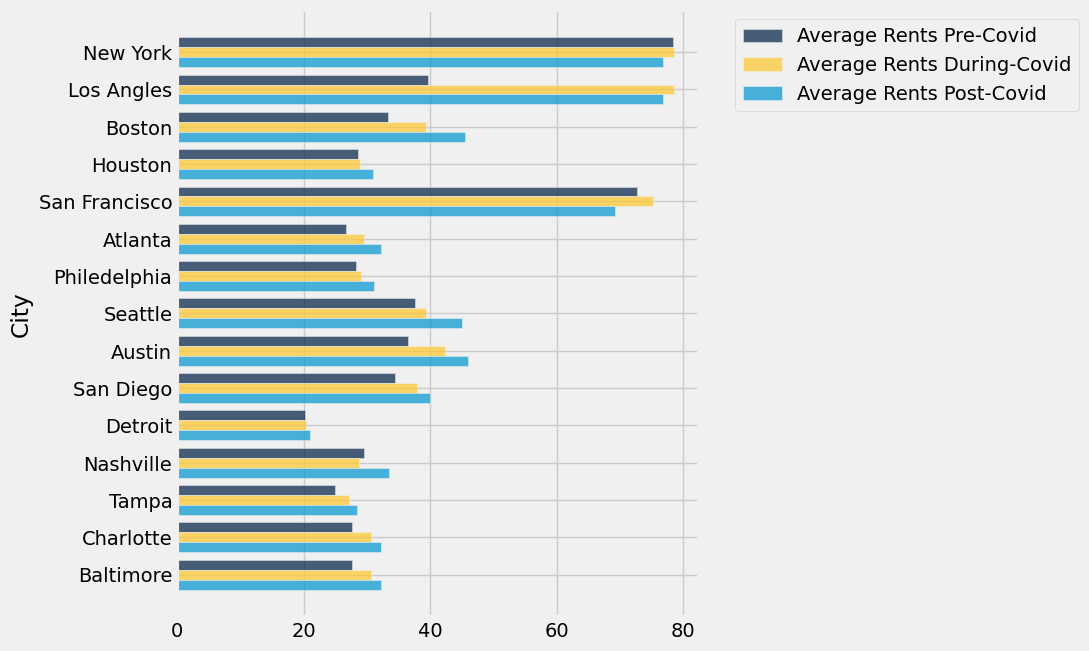

In [28]:
#DESCRIPTION OF GRAPH: COMPARISON GRAPH OF RENT PRICES IN KEY STATES PRE, DURING, AND POST COVID
avgRentTable.barh('City', ['Average Rents Pre-Covid', 'Average Rents During-Covid', 'Average Rents Post-Covid'])

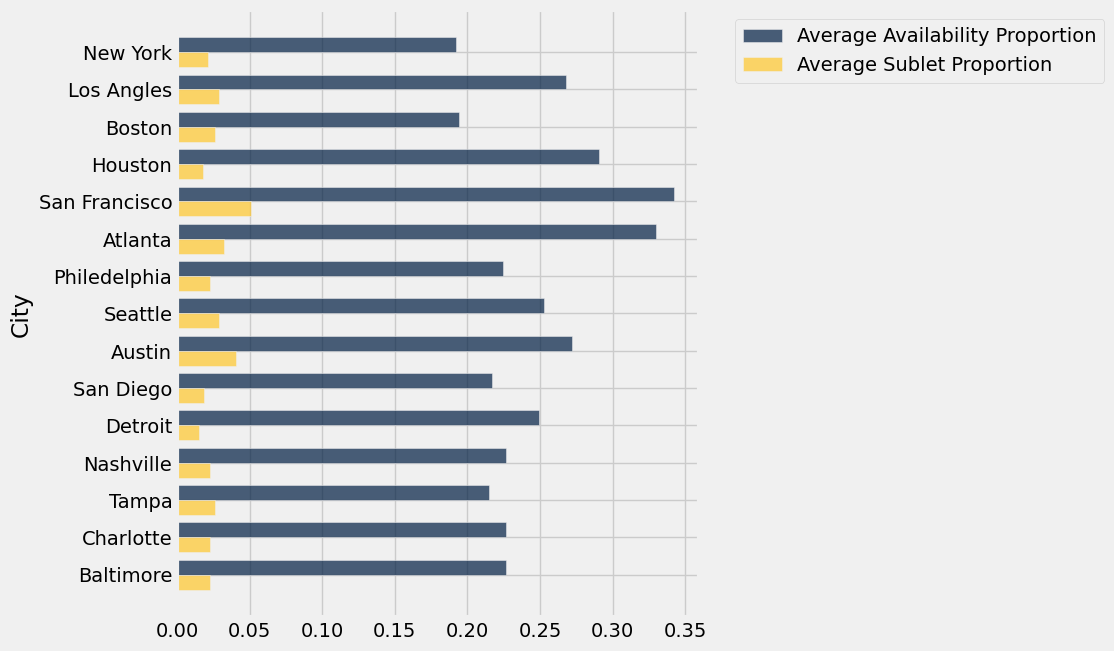

In [29]:
#DESCRIPTION OF GRAPH: COMAPARISON GRAPH OF AVAILABILITY PROPORTION AND SUBLET PROPORTION FOR KEY STATES (ONLY POST)
avgRentTable.barh('City', ['Average Availability Proportion', 'Average Sublet Proportion'])

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4487cead-9e45-4286-b5b8-37614f9dfcb9' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>